# Swin-S per attack

Swin-S restricts attention to shifted windows, so a trigger's tokens reach the class decision through a different route than in ViT-B/16. The paper reports a mean over every implanted Swin model, and this notebook breaks it out by attack. It compares PSBD-TM against PSBD-RD on the models `scripts/paper/tab_swin.py` reads, the panel-shaped `results/swin_*` folders whose attack success clears the declared bar, at the adaptive rate rule and the headline quantile. It reads cached JSON only and runs in a few seconds.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from defenses.decision import (
    HEADLINE_QUANTILE,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
)
from scripts.paper._common import (
    HEADLINE_KEY,
    OKABE_ITO,
    attack_label,
    dataset_label,
    load_declaration,
)
from scripts.paper._style import TEXT_WIDTH
from scripts.paper.tab_swin import HEADLINE_RULE, reading, swin_cells

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

## The Swin models

Swin has no coverage ledger of its own, so the generator's `swin_cells` scans the folders directly and keeps the ones whose training sidecar records an attack success above the bar in `configs/psbd_basis.json`.

In [4]:
declaration = load_declaration("configs/psbd_basis.json")
cells = swin_cells("results", "checkpoints", declaration["asr_bar"])

per_model = pd.DataFrame(
    [
        {
            "attack": attack_label(cell["attack"]),
            "dataset": dataset_label(cell["dataset"]),
            "poison rate": cell["poison_rate"],
            "PSBD-TM": reading(
                cell["report"],
                RECOMMENDED_PLACEMENT,
                HEADLINE_RULE,
                HEADLINE_KEY,
                "auroc",
            ),
            "PSBD-RD": reading(
                cell["report"],
                PUBLISHED_PLACEMENT,
                HEADLINE_RULE,
                HEADLINE_KEY,
                "auroc",
            ),
        }
        for cell in cells
    ]
)
print(f"{len(cells)} implanted Swin models above the {declaration['asr_bar']} bar")
print(
    f"rule {HEADLINE_RULE}, threshold at the {HEADLINE_QUANTILE:.0%} clean-validation quantile"
)
per_model.groupby("dataset").size().rename("models")

90 implanted Swin models above the 0.85 bar
rule adaptive, threshold at the 25% clean-validation quantile


dataset
CIFAR-10         26
CIFAR-100        24
GTSRB            22
Tiny ImageNet    18
Name: models, dtype: int64

## Paired means per attack

A placement whose rate ladder never reaches the adaptive shift target has no reading on that model. The table counts those models per attack and computes each attack's means and gain over the models carrying both placements, so the 2 columns always average the same models.

In [5]:
missing = per_model.groupby("attack")[["PSBD-TM", "PSBD-RD"]].agg(
    lambda column: column.isna().sum()
)
paired = per_model.dropna(subset=["PSBD-TM", "PSBD-RD"])

per_attack = paired.groupby("attack").agg(
    models=("PSBD-TM", "size"),
    tm=("PSBD-TM", "mean"),
    rd=("PSBD-RD", "mean"),
)
per_attack["gain"] = per_attack["tm"] - per_attack["rd"]
per_attack["TM unreached"] = missing["PSBD-TM"]
per_attack["RD unreached"] = missing["PSBD-RD"]
per_attack = per_attack.sort_values("gain", ascending=False)

overall_gain = (paired["PSBD-TM"] - paired["PSBD-RD"]).mean()
attacks_gaining = (per_attack["gain"] > 0).sum()
print(f"{len(paired)} of {len(per_model)} models carry both placements")
print(
    f"paired gain over every model {overall_gain:+.3f}, positive on {attacks_gaining} of {len(per_attack)} attacks"
)
per_attack.round(3)

86 of 90 models carry both placements
paired gain over every model +0.118, positive on 6 of 9 attacks


,models,tm,rd,gain,TM unreached,RD unreached
attack,,,,,,
Label-Consistent,4,0.989,0.529,0.461,0,0
WaNet,8,0.944,0.615,0.329,0,0
BadNets,15,0.999,0.754,0.245,0,0
TaCT,6,0.711,0.552,0.158,3,0
LF,15,0.968,0.862,0.106,0,0
SIG,1,0.954,0.937,0.017,1,0
Blend,15,0.994,0.998,-0.004,0,0
BPP,15,0.958,0.975,-0.017,0,0
Adaptive-Blend,7,0.899,0.938,-0.040,0,0


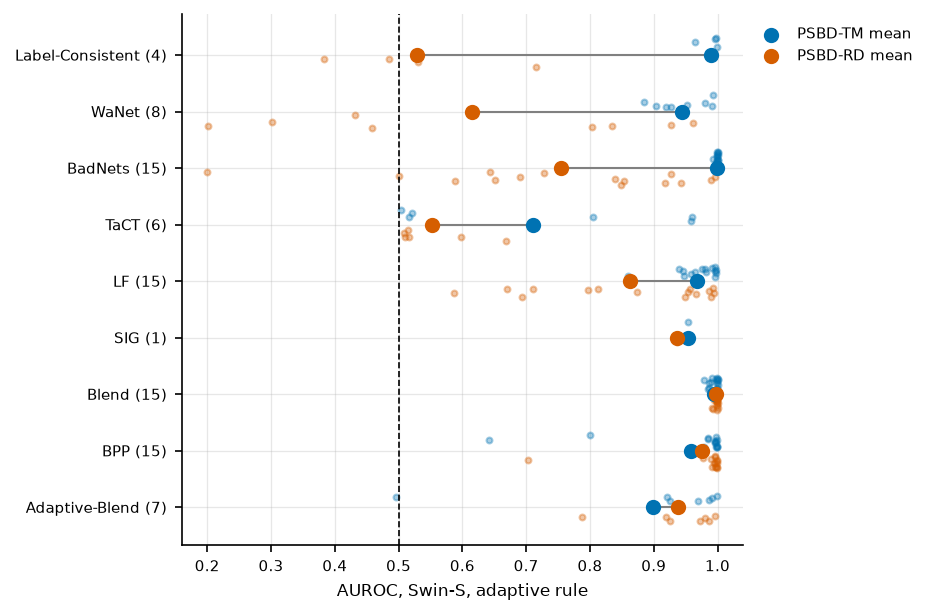

In [6]:
figure, axis = plt.subplots(figsize=(TEXT_WIDTH * 0.7, 0.4 * len(per_attack) + 1.0))
rows = np.arange(len(per_attack))  # (attacks,)
jitter = np.random.default_rng(0)

# Every model sits behind its attack's means as a faint point, so a mean over 2
# models cannot pass for a mean over 15.
for row_index, attack in enumerate(per_attack.index):
    models = paired[paired["attack"] == attack]
    offsets = jitter.uniform(-0.12, 0.12, size=len(models))  # (models,)
    axis.scatter(
        models["PSBD-RD"],
        row_index + 0.18 + offsets,
        color=OKABE_ITO[1],
        alpha=0.35,
        s=8,
    )
    axis.scatter(
        models["PSBD-TM"],
        row_index - 0.18 + offsets,
        color=OKABE_ITO[0],
        alpha=0.35,
        s=8,
    )

axis.hlines(rows, per_attack["rd"], per_attack["tm"], color="gray", linewidth=1.0)
axis.scatter(
    per_attack["tm"], rows, color=OKABE_ITO[0], s=40, zorder=3, label="PSBD-TM mean"
)
axis.scatter(
    per_attack["rd"], rows, color=OKABE_ITO[1], s=40, zorder=3, label="PSBD-RD mean"
)
axis.axvline(0.5, color="black", linewidth=0.8, linestyle="--")
axis.set_yticks(
    rows,
    labels=[
        f"{attack} ({n})" for attack, n in zip(per_attack.index, per_attack["models"])
    ],
)
axis.invert_yaxis()
axis.set_xlabel("AUROC, Swin-S, adaptive rule")
axis.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()

## Reading the Swin breakdown

The Swin mean gain is carried by the local triggers. Label-Consistent, WaNet, TaCT and BadNets gain the most, with PSBD-RD close to chance on Label-Consistent and WaNet while PSBD-TM stays close to 1. The global triggers Blend, BPP and Adaptive-Blend are detected well by both placements, and PSBD-RD is slightly ahead on all 3. TaCT is the attack where the adaptive rule most often finds no rate for either placement, so its paired mean rests on a small part of the models it trained, and SIG rests on a single model. The split matches ViT-B/16 with 1 exception, WaNet, which PSBD-RD detects best of every defense on ViT-B/16 in `detectors-per-attack.ipynb` and barely above chance on Swin-S.